In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import array
import numpy as np
from scipy import stats 
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
import community as community_louvain  # pip install python-louvain

In [4]:
file = "subelj_euroroad/out.subelj_euroroad_euroroad"
G = nx.read_edgelist(file, comments='%', nodetype=int)

print(f"Number of nodes: {G.number_of_nodes()}") 
print(f"Number of links: {G.number_of_edges()}")
#print(f"Average path length:{nx.average_shortest_path_length(G_lcc)}")

avg_path_real = nx.average_shortest_path_length(G.subgraph(max(nx.connected_components(G), key=len)))
print(avg_path_real)

Number of nodes: 1174
Number of links: 1417
18.39514614059391


# assignment 1

In [5]:
N = G.number_of_nodes()
E = G.number_of_edges()

D = array.array('i', [0] * (N + 1))
for u, v in G.edges():
    D[u] += 1
    D[v] += 1

P = array.array('i', [0] * (N + 2))
for i in range(1, N + 1):
    P[i+1] = P[i] + D[i]

V = array.array('i', [0] * (2 * E))
current_pos = array.array('i', P)
for u, v in G.edges():
    V[current_pos[u]] = v
    V[current_pos[v]] = u
    current_pos[u] += 1
    current_pos[v] += 1

start = P[7]
end = P[8]
nodeslinkedwith7 = V[start:end]
print(nodeslinkedwith7)

array('i', [6, 8, 22, 23, 411, 453, 454, 889])


In [6]:
def build_network(filename, N, E):
    D = array.array('i', [0] * (N + 1))
    edges_temp = []
    with open(filename, 'r') as f:
        for line in f:
            if line.startswith('%') or not line.strip():
                continue
            parts = line.split()
            if len(parts) >= 2:
                u, v = int(parts[0]), int(parts[1])
                D[u] += 1
                D[v] += 1
                edges_temp.append((u, v))
    P = array.array('i', [0] * (N + 2))
    for i in range(1, N + 1):
        P[i+1] = P[i] + D[i]
    V = array.array('i', [0] * (2 * E))
    current_pos = array.array('i', P)
    for u, v in edges_temp:
        V[current_pos[u]] = v
        V[current_pos[v]] = u
        current_pos[u] += 1
        current_pos[v] += 1
    return D, P, V


N_nodos = N
E_aristas = E
archivo = file

D, P, V = build_network(archivo, N_nodos, E_aristas)
inicio = P[7]
fin = P[8]
print(f"Grado del nodo 7: {D[7]}")
print(f"Vecinos del nodo 7 en el vector V: {list(V[inicio:fin])}")

avg_degree = (2 * E) / N

print(f"Nodes: {N}")
print(f"Links: {E}")
print(f"Average degree: {avg_degree:.4f}")

Grado del nodo 7: 8
Vecinos del nodo 7 en el vector V: [6, 8, 22, 23, 411, 453, 454, 889]
Nodes: 1174
Links: 1417
Average degree: 2.4140


In [7]:
#llista de tots els graus
with open('degree_list.txt', 'w') as f:
    for node in range(1, N + 1):
        f.write(f"{node} {D[node]}\n")

In [8]:
cities = "subelj_euroroad/ent.subelj_euroroad_euroroad.city.name" 
names = {}

with open(cities, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f, 1):
        names[i] = line.strip()
print(f"Node 1: {names[1]}")
print(f"Node 2: {names[2]}")

Node 1: Greenock
Node 2: Glasgow


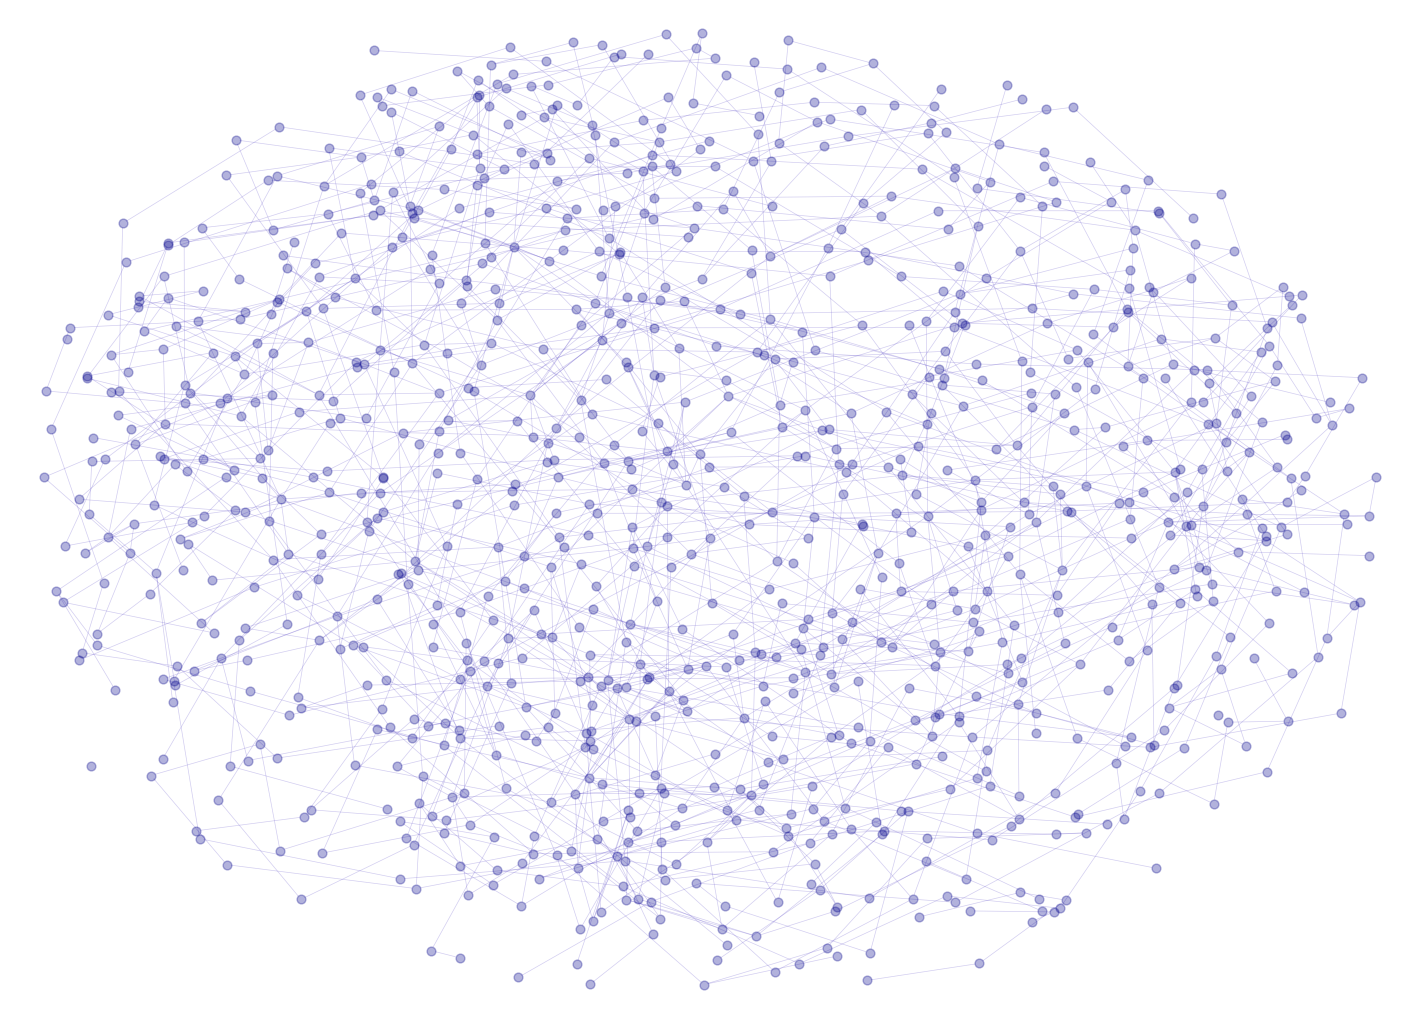

In [9]:
plt.figure(figsize=(14, 10))
nodes_with_edges = [node for node, degree in G.degree() if degree > 1]
sub = G.subgraph(nodes_with_edges)
pos = nx.spring_layout(sub, k=0.15, seed=42)
nx.draw(sub, pos, node_size=40, node_color='darkblue', edge_color='slateblue', alpha=0.3, width=0.5, arrows=True, arrowsize=10)
sub_labels = {node: names[node] for node in sub.nodes()}

#ajusto els margens perque despres no ocupin massa espai al overleaf
x_values = [coords[0] for coords in pos.values()]
y_values = [coords[1] for coords in pos.values()]
margin = 0.05
plt.xlim(min(x_values) - margin, max(x_values) + margin)
plt.ylim(min(y_values) - margin, max(y_values) + margin)
plt.savefig('figs/network.png', dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

In [ ]:
listdegrees = [degree for node, degree in G.degree()]
print(f"List of degrees (first 10): {listdegrees[:10]}")

average_k = (2 * E) / N
print(f"Average k: {average_k:.2f}")

max_val = np.max(listdegrees)
nodo_max = listdegrees.index(max_val) + 1

print(f"La ciudad con más conexiones es {names[nodo_max]} (ID: {nodo_max}) con un grado de {max_val}")

List of degrees (first 10): [1, 3, 2, 3, 3, 1, 2, 2, 8, 2]
Average k: 2.41
La ciudad con más conexiones es Belfort (ID: 485) con un grado de 10


In [ ]:
betweenness_dict = nx.betweenness_centrality(G)
nodo_max_id = max(betweenness_dict, key=betweenness_dict.get)
valor_max = betweenness_dict[nodo_max_id]
nombre_ciudad = names.get(nodo_max_id, "Nombre no encontrado en el archivo")

print(f"El nodo con mayor intermediación (betweenness) es: {nombre_ciudad}")
print(f"ID del nodo: {nodo_max_id}")
print(f"Valor de centralidad: {valor_max:.4f}")

El nodo con mayor intermediación (betweenness) es: Brest
ID del nodo: 402
Valor de centralidad: 0.2148


In [ ]:
degree_dict = nx.degree_centrality(G)
node_max_deg = max(degree_dict, key=degree_dict.get)
val_max_deg = degree_dict[node_max_deg]
name_max_deg = names.get(node_max_deg, "Nombre no encontrado")

betweenness_dict = nx.betweenness_centrality(G)
node_max_btw = max(betweenness_dict, key=betweenness_dict.get)
val_max_btw = betweenness_dict[node_max_btw]
name_max_btw = names.get(node_max_btw, "Nombre no encontrado")

print(f"Max Degree Centrality    | Node ID: {node_max_deg} | City: {name_max_deg} | Value: {val_max_deg:.4f}")
print(f"Max Betweenness Centrality | Node ID: {node_max_btw} | City: {name_max_btw} | Value: {val_max_btw:.4f}")

Max Degree Centrality    | Node ID: 284 | City: Moscow | Value: 0.0096
Max Betweenness Centrality | Node ID: 402 | City: Brest | Value: 0.2743


# assignment 2

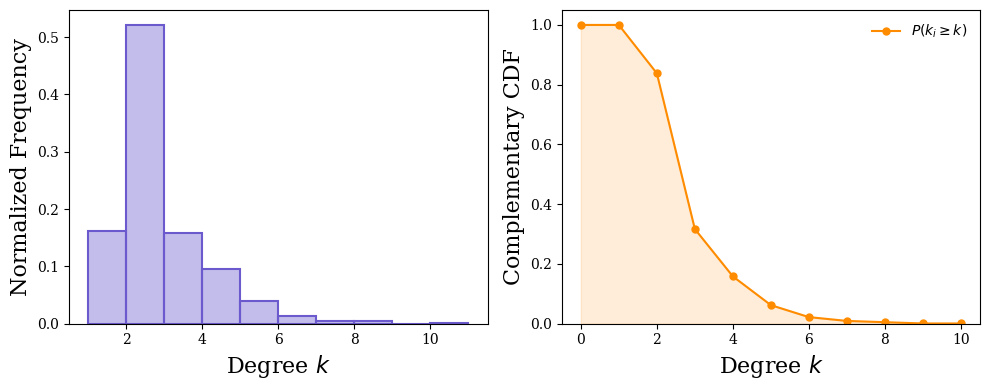

In [14]:
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

listdegrees = list(D[1:])
max_k = max(listdegrees)

pk = np.zeros(max_k + 1)
for k in listdegrees:
    pk[k] += 1
pk = pk / len(listdegrees)

ccpk = np.zeros(max_k + 1)
for k in range(max_k + 1):
    ccpk[k] = np.sum(pk[k:])

plt.rcParams["font.family"] = "serif"
os.makedirs("figs", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(
    listdegrees,
    bins=range(min(listdegrees), max_k + 2),
    stat="density",
    color="slateblue",
    edgecolor="slateblue",
    alpha=0.4,
    linewidth=1.5,
    ax=axes[0],
)
axes[0].set_xlabel("Degree $k$", fontsize=16)
axes[0].set_ylabel("Normalized Frequency", fontsize=16)
axes[0].grid(False)

axes[1].plot(
    range(len(ccpk)),
    ccpk,
    marker="o",
    markersize=5,
    linestyle="-",
    color="darkorange",
    linewidth=1.5,
    label="$P(k_i \geq k)$",
)
axes[1].fill_between(range(len(ccpk)), ccpk, color="darkorange", alpha=0.15)
axes[1].set_xlabel("Degree $k$", fontsize=16)
axes[1].set_ylabel("Complementary CDF", fontsize=16)
axes[1].set_ylim(0, 1.05)
axes[1].grid(False)
axes[1].legend(frameon=False)

plt.tight_layout()
plt.savefig("figs/degree_plots.png", dpi=300, bbox_inches="tight")

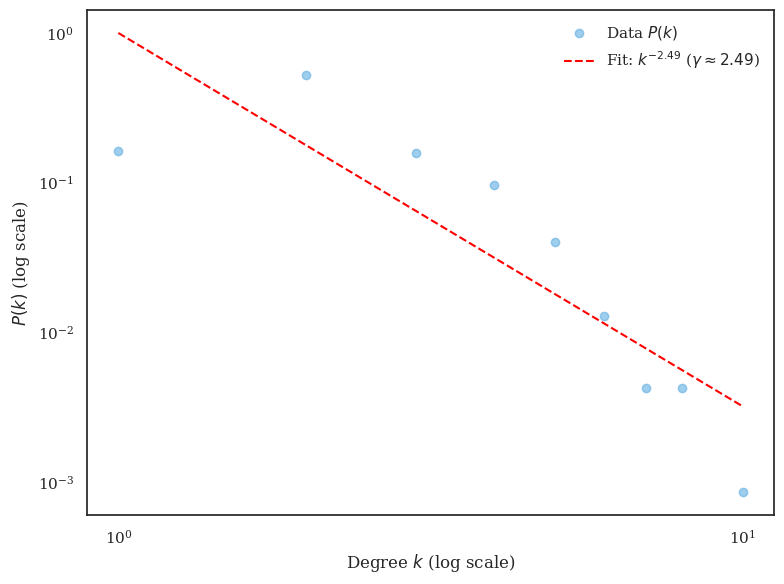

El exponente gamma estimado es: 2.4939
R^2:0.7410
p-value: 2.8822e-03
El ajuste es estadísticamente significativo (p < 0.05).


In [ ]:
sns.set_theme(style="white")
plt.rcParams['font.family'] = 'serif'

k_vals = np.array(range(len(pk)))
mask = pk > 0
k_log = np.log(k_vals[mask])
pk_log = np.log(pk[mask])

coeffs = np.polyfit(k_log, pk_log, 1)
gamma = -coeffs[0]
fit_line = np.exp(coeffs[1]) * (k_vals[mask]**coeffs[0])

plt.figure(figsize=(8, 6))
plt.scatter(k_vals[mask], pk[mask], color='#5dade2', alpha=0.6, label='Data $P(k)$')
plt.plot(k_vals[mask], fit_line, color='red', linestyle='--', 
         label=f'Fit: $k^{{{coeffs[0]:.2f}}}$ ($\\gamma \\approx {gamma:.2f}$)')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Degree $k$ (log scale)', fontsize=12)
plt.ylabel('$P(k)$ (log scale)', fontsize=12)
#plt.title('Log-Log Degree Distribution & Power Law Fit', fontsize=14, fontweight='bold')
plt.grid(False)
plt.legend(frameon=False)

plt.tight_layout()
plt.show()

print(f"El exponente gamma estimado es: {gamma:.4f}")

slope, intercept, r_value, p_value, std_err = stats.linregress(k_log, pk_log)
r_squared = r_value**2
gamma=-slope
print(f"R^2:{r_squared:.4f}")
print(f"p-value: {p_value:.4e}")

# 4. Criterio de significancia
if p_value < 0.05:
    print("El ajuste es estadísticamente significativo (p < 0.05).")
else:
    print("El ajuste NO es estadísticamente significativo (p >= 0.05).")


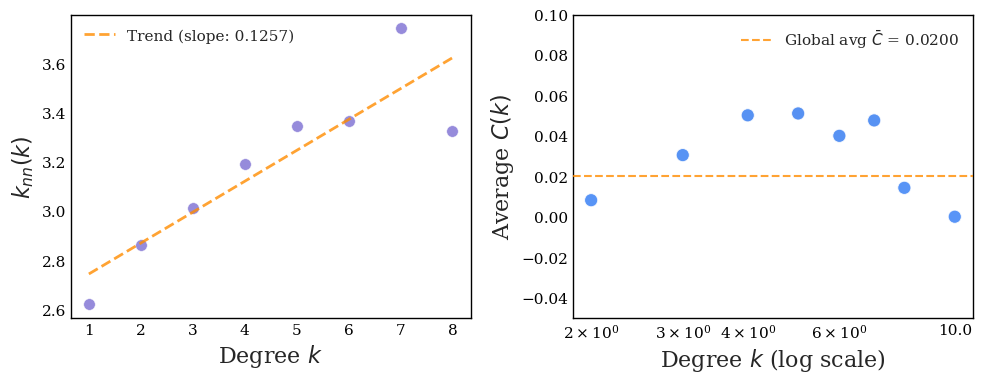

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

max_k = max(D)
nk = np.zeros(max_k + 1)
for k in D[1:]:
    nk[k] += 1
knn = np.zeros(max_k + 1)
for i in range(1, N + 1):
    ki = D[i]
    if ki > 0:
        sum_kj = 0
        for idx in range(P[i], P[i + 1]):
            neighbor_idx = V[idx]
            sum_kj += D[neighbor_idx]
        knn[ki] += sum_kj / (ki * nk[ki])
k_coords = [k for k in range(1, max_k + 1) if nk[k] > 0 and k != 10]
knn_coords = [knn[k] for k in k_coords]

adj = np.zeros((N + 1, N + 1), dtype=np.int8)
for i in range(1, N + 1):
    for idx in range(P[i], P[i + 1]):
        adj[i][V[idx]] = 1

max_k_c = max(D[1:])
nk_c = np.zeros(max_k_c + 1)
for k in D[1:]:
    nk_c[k] += 1

local_C = np.zeros(N + 1)
Ck = np.zeros(max_k_c + 1)

for i in range(1, N + 1):
    ki = D[i]
    if ki < 2:
        local_C[i] = 0.0
        continue
    neighbors = V[P[i] : P[i + 1]]
    triangles = 0
    for idx_u in range(len(neighbors)):
        u = neighbors[idx_u]
        for idx_v in range(idx_u + 1, len(neighbors)):
            v = neighbors[idx_v]
            if adj[u][v] == 1:
                triangles += 1
    max_triangles = ki * (ki - 1) / 2
    local_C[i] = triangles / max_triangles
    Ck[ki] += local_C[i]

k_vals = [k for k in range(2, max_k_c + 1) if nk_c[k] > 0]
ck_vals = [Ck[k] / nk_c[k] for k in k_vals]
valid_nodes = [i for i in range(1, N + 1) if D[i] >= 2]
avg_C = np.mean([local_C[i] for i in valid_nodes])

sns.set_theme(style="white")
plt.rcParams["font.family"] = "serif"
PURPLE = "#1e3a8a"
LAVENDER = "#3b82f6"
BG = "#ffffff"
os.makedirs("figs", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(k_coords,knn_coords,color="slateblue",s=70,alpha=0.7,edgecolor="white",linewidth=0.5,zorder=3,)
coeffs = np.polyfit(k_coords, knn_coords, 1)
trendline = np.poly1d(coeffs)
axes[0].plot(k_coords,trendline(k_coords),color="darkorange",linestyle="--",alpha=0.8,linewidth=2,label=f"Trend (slope: {coeffs[0]:.4f})",zorder=4,)
axes[0].set_xlabel(r"Degree $k$", fontsize=16)
axes[0].set_ylabel(r"$k_{nn}(k)$", fontsize=16)
axes[0].legend(frameon=False, fontsize=11)
axes[0].grid(False)

cmap = LinearSegmentedColormap.from_list("pur", [LAVENDER, PURPLE])
axes[1].scatter(
    k_vals,
    ck_vals,
    c=ck_vals,
    cmap=cmap,
    vmin=0,
    vmax=1,
    s=90,
    alpha=0.85,
    edgecolor="white",
    linewidth=0.7,
    zorder=3,
)
axes[1].axhline(
    avg_C,
    color="darkorange",
    linewidth=1.5,
    linestyle="--",
    alpha=0.8,
    label=f"Global avg $\\bar{{C}}$ = {avg_C:.4f}",
    zorder=4,
)
axes[1].set_xscale("log")
axes[1].set_ylim(-0.05, 0.10)
axes[1].set_xlabel(r"Degree $k$ (log scale)", fontsize=16)
axes[1].set_ylabel(r"Average $C(k)$", fontsize=16)
axes[1].grid(False)
axes[1].xaxis.set_major_formatter(ticker.ScalarFormatter())
axes[1].legend(fontsize=11, frameon=False, loc="upper right")

for ax in axes:
    ax.tick_params(
        which="both", direction="in", length=4, labelsize=11, colors="black"
    )
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1.0)

plt.tight_layout()
plt.savefig("figs/knn_and_clustering.png", dpi=300, bbox_inches="tight", facecolor=BG)
plt.show()

since the slope is positive (0.1257) the network is assortative, nodes tend to connect with nodes that have similar degree

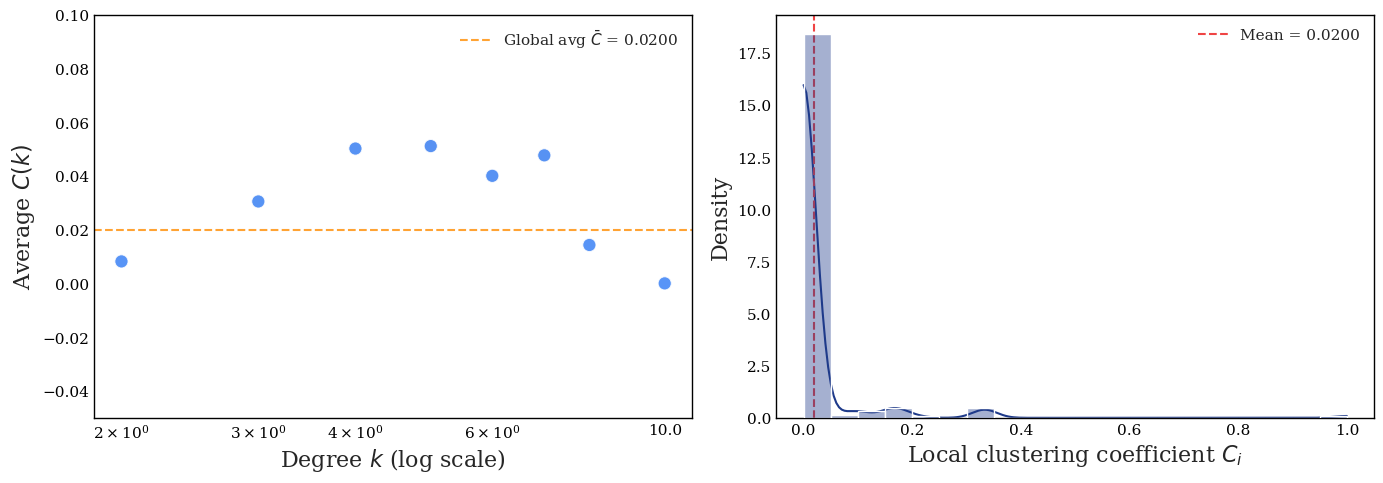

In [19]:
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

adj = np.zeros((N + 1, N + 1), dtype=np.int8)
for i in range(1, N + 1):
    for idx in range(P[i], P[i + 1]):
        adj[i][V[idx]] = 1

max_k = max(D[1:])
nk = np.zeros(max_k + 1)
for k in D[1:]:
    nk[k] += 1

local_C = np.zeros(N + 1)
Ck = np.zeros(max_k + 1)

for i in range(1, N + 1):
    ki = D[i]
    if ki < 2:
        local_C[i] = 0.0
        continue
    neighbors = V[P[i] : P[i + 1]]
    triangles = 0
    for idx_u in range(len(neighbors)):
        u = neighbors[idx_u]
        for idx_v in range(idx_u + 1, len(neighbors)):
            v = neighbors[idx_v]
            if adj[u][v] == 1:
                triangles += 1
    max_triangles = ki * (ki - 1) / 2
    local_C[i] = triangles / max_triangles
    Ck[ki] += local_C[i]

k_vals = [k for k in range(2, max_k + 1) if nk[k] > 0]
ck_vals = [Ck[k] / nk[k] for k in k_vals]
valid_nodes = [i for i in range(1, N + 1) if D[i] >= 2]
avg_C = np.mean([local_C[i] for i in valid_nodes])

plt.rcParams["font.family"] = "serif"
PURPLE = "#1e3a8a"
LAVENDER = "#3b82f6"
BG = "#ffffff"
os.makedirs("figs", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cmap = LinearSegmentedColormap.from_list("pur", [LAVENDER, PURPLE])
axes[0].scatter(
    k_vals,
    ck_vals,
    c=ck_vals,
    cmap=cmap,
    vmin=0,
    vmax=1,
    s=90,
    alpha=0.85,
    edgecolor="white",
    linewidth=0.7,
    zorder=3,
)
axes[0].axhline(
    avg_C,
    color="darkorange",
    linewidth=1.5,
    linestyle="--",
    alpha=0.8,
    label=f"Global avg $\\bar{{C}}$ = {avg_C:.4f}",
)
axes[0].set_xscale("log")
axes[0].set_ylim(-0.05, 0.10)
axes[0].set_xlabel(r"Degree $k$ (log scale)", fontsize=16)
axes[0].set_ylabel(r"Average $C(k)$", fontsize=16)
axes[0].grid(False)
axes[0].xaxis.set_major_formatter(ticker.ScalarFormatter())
axes[0].tick_params(
    which="both", direction="in", length=4, labelsize=11, colors="black"
)
axes[0].legend(fontsize=11, frameon=False, loc="upper right")

ci_vals = [local_C[i] for i in range(1, N + 1) if D[i] >= 2]
sns.histplot(
    ci_vals,
    bins=20,
    kde=True,
    color=PURPLE,
    edgecolor="white",
    linewidth=1,
    alpha=0.4,
    stat="density",
    zorder=3,
    ax=axes[1],
)
axes[1].axvline(
    avg_C,
    color="#ef4444",
    linewidth=1.5,
    linestyle="--",
    label=f"Mean = {avg_C:.4f}",
)
axes[1].set_xlim(-0.05, 1.05)
axes[1].set_xlabel("Local clustering coefficient $C_i$", fontsize=16)
axes[1].set_ylabel("Density", fontsize=16)
axes[1].grid(False)
axes[1].tick_params(
    which="both", direction="in", length=4, labelsize=11, colors="black"
)
axes[1].legend(fontsize=11, frameon=False)

for ax in axes:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1.0)

plt.tight_layout()
plt.savefig(
    "figs/clustering_combined.png", dpi=300, bbox_inches="tight", facecolor=BG
)
plt.show()

In [ ]:
avg_k = sum(D[1:]) / N
C_esperado = avg_k / N
print(f"⟨k⟩ = {avg_k:.4f}")
print(f"C esperado (ER) = {C_esperado:.6f}")
print(f"C medido        = {avg_C:.6f}")

⟨k⟩ = 2.4140
C esperado (ER) = 0.002056
C medido        = 0.019962


In [ ]:
adj = np.zeros((N + 1, N + 1), dtype=np.int8)
for i in range(1, N + 1):
    for idx in range(P[i], P[i + 1]):
        adj[i][V[idx]] = 1

max_k = max(D[1:])
nk    = np.zeros(max_k + 1)
for k in D[1:]:
    nk[k] += 1

local_C = np.zeros(N + 1)
Ck      = np.zeros(max_k + 1)

for i in range(1, N + 1):
    ki = D[i]
    if ki < 2:
        local_C[i] = 0.0
        continue
    neighbors = V[P[i]:P[i + 1]]
    triangles = 0
    for idx_u in range(len(neighbors)):
        u = neighbors[idx_u]
        for idx_v in range(idx_u + 1, len(neighbors)):
            v = neighbors[idx_v]
            if adj[u][v] == 1:
                triangles += 1
    max_triangles = ki * (ki - 1) / 2
    local_C[i]   = triangles / max_triangles
    Ck[ki]       += local_C[i]

k_vals  = [k for k in range(2, max_k + 1) if nk[k] > 0]
ck_vals = [Ck[k] / nk[k] for k in k_vals]

valid_nodes = [i for i in range(1, N + 1) if D[i] >= 2]
avg_C = np.mean([local_C[i] for i in valid_nodes])
avg_k = sum(D[1:]) / N
C_er  = avg_k / N

print("=" * 45)
print(f"  N                      : {N}")
print(f"  Nodes analysed (k ≥ 2) : {len(valid_nodes)}")
print(f"  ⟨k⟩                    : {avg_k:.4f}")
print(f"  Global avg C           : {avg_C:.6f}")
print(f"  C expected (ER)        : {C_er:.6f}")
print(f"  C / C_ER               : {avg_C / C_er:.2f}x")
print("=" * 45)

zeros = [(k, ck) for k, ck in zip(k_vals, ck_vals) if ck == 0]
print(f"\n  k values with C(k)=0  : {zeros}\n")

valid_fit = [(k, ck) for k, ck in zip(k_vals, ck_vals) if ck > 0]
k_fit     = [v[0] for v in valid_fit]
ck_fit    = [v[1] for v in valid_fit]

log_k  = np.log10(k_fit)
log_ck = np.log10(ck_fit)
slope, intercept, r, _, _ = linregress(log_k, log_ck)
r2 = r ** 2

print(f"  Power-law exponent α   : {slope:.4f}")
print(f"  R²                     : {r2:.4f}")
print("=" * 45)

# ── 7. Plot ───────────────────────────────────
sns.set_theme(style="white")
PURPLE = "#8e44ad"
BG     = "#fdfcff"

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

# all empirical points
ax.scatter(k_vals, ck_vals,
           color=PURPLE, s=75, alpha=0.85,
           edgecolor="white", linewidth=0.6,
           label="$C(k)$ empirical", zorder=3)

# power-law fit line
fit_x = np.linspace(min(log_k), max(log_k), 300)
fit_y = slope * fit_x + intercept

# reference lines
ax.axhline(avg_C, color=PURPLE, linewidth=1.2, linestyle="--", alpha=0.5,
           label=f"$\\bar{{C}}$ = {avg_C:.4f}")
ax.axhline(C_er,  color="gray",   linewidth=1.2, linestyle=":",  alpha=0.7,
           label=f"$C_{{ER}}$ = {C_er:.4f}")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Degree $k$", fontsize=13)
ax.set_ylabel(r"$C(k)$",     fontsize=13)
ax.set_title("Clustering Coefficient $C(k)$",
             fontsize=14, fontweight="bold", pad=14)
ax.legend(fontsize=10, framealpha=0.8)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.tick_params(which="both", direction="in", length=4)
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig("clustering_coefficient.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()

  N                      : 1174
  Nodes analysed (k ≥ 2) : 984
  ⟨k⟩                    : 2.4140
  Global avg C           : 0.019962
  C expected (ER)        : 0.002056
  C / C_ER               : 9.71x

  k values with C(k)=0  : [(10, np.float64(0.0))]



NameError: name 'linregress' is not defined

# assignment 3

Full Network  | Nodes: 1174 | Edges: 1417
Giant Comp.   | Nodes: 1039 | Edges: 1305
Communities found : 22
Modularity Q      : 0.8685


C:\Users\34633\AppData\Local\Temp\ipykernel_22020\2864907863.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", n_communities)


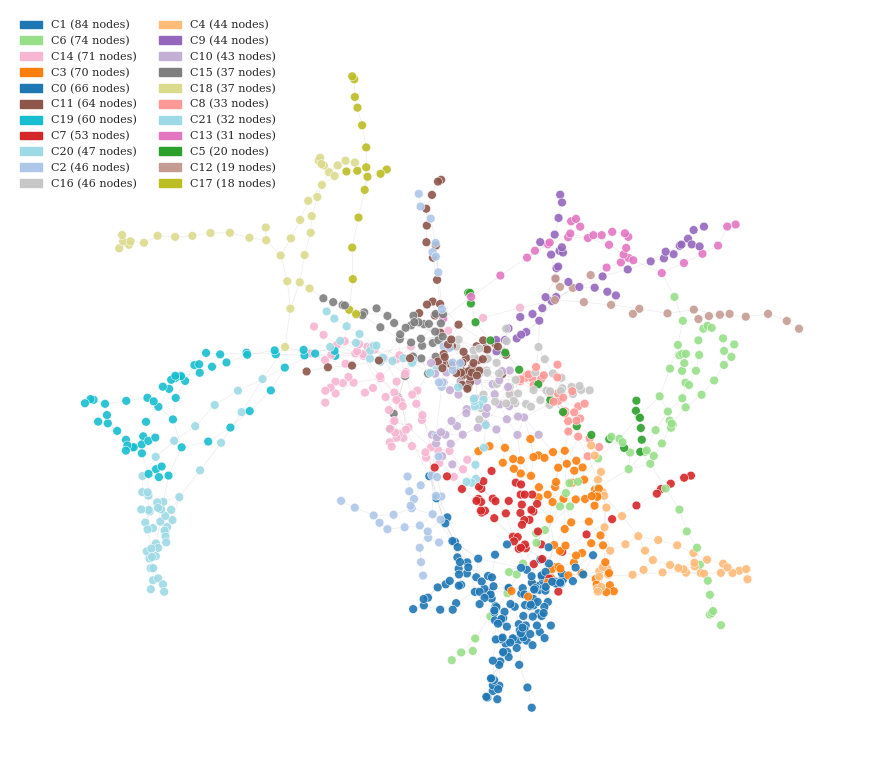

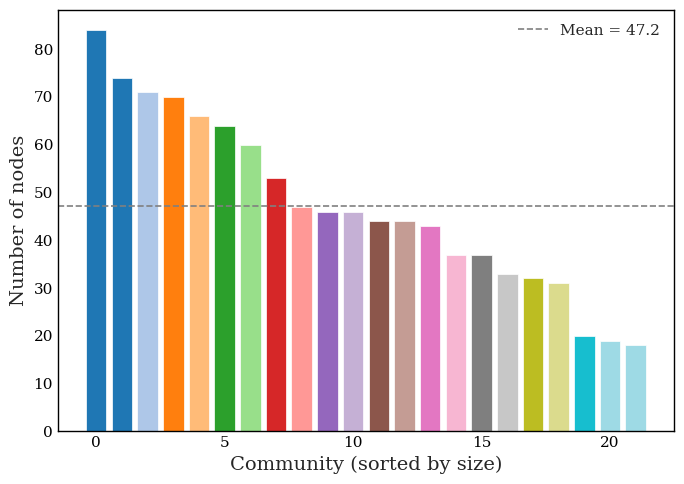

In [ ]:
import matplotlib.patches as mpatches
from collections import Counter
import networkx as nx
import community as community_louvain

G_full = nx.Graph()
G_full.add_nodes_from(range(1, N + 1))
for i in range(1, N + 1):
    for idx in range(P[i], P[i + 1]):
        j = V[idx]
        if i < j:
            G_full.add_edge(i, j)

giant_components = sorted(nx.connected_components(G_full), key=len, reverse=True)
G = G_full.subgraph(giant_components[0]).copy()

print(f"Full Network  | Nodes: {G_full.number_of_nodes()} | Edges: {G_full.number_of_edges()}")
print(f"Giant Comp.   | Nodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()}")

partition = community_louvain.best_partition(G, random_state=42)
n_communities = len(set(partition.values()))
modularity = community_louvain.modularity(partition, G)

print(f"Communities found : {n_communities}")
print(f"Modularity Q      : {modularity:.4f}")

sizes = Counter(partition.values())

plt.rcParams['font.family'] = 'serif'
cmap = plt.cm.get_cmap("tab20", n_communities)
colors = [cmap(partition[n]) for n in G.nodes()]
BG = "#ffffff"
os.makedirs('figs', exist_ok=True)

pos = nx.spring_layout(G, seed=42, k=0.8)


plt.figure(figsize=(9, 8))
ax = plt.gca()
ax.set_facecolor(BG)

nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.15, width=0.5, edge_color="gray")
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colors, node_size=40, alpha=0.9,edgecolors='white', linewidths=0.4)

handles = [
    mpatches.Patch(color=cmap(cid), label=f"C{cid} ({sizes[cid]} nodes)")
    for cid in sorted(sizes, key=lambda x: -sizes[x])
]
ax.legend(handles=handles, fontsize=8, loc="upper left", framealpha=0.8, ncol=2, frameon=False)
ax.axis("off")

plt.tight_layout()
plt.savefig("figs/louvain_network.png", dpi=300, bbox_inches="tight", facecolor=BG)
plt.show()

plt.figure(figsize=(7, 5))
ax2 = plt.gca()
ax2.set_facecolor(BG)

sorted_sizes = sorted(sizes.values(), reverse=True)
bar_colors = [cmap(i) for i in range(len(sorted_sizes))]

ax2.bar(range(len(sorted_sizes)), sorted_sizes, color=bar_colors, edgecolor="white", linewidth=0.5)
ax2.set_xlabel("Community (sorted by size)", fontsize=14)
ax2.set_ylabel("Number of nodes", fontsize=14)
ax2.axhline(np.mean(sorted_sizes), color="gray", linestyle="--", linewidth=1.2, label=f"Mean = {np.mean(sorted_sizes):.1f}")
ax2.grid(False)

for spine in ax2.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.0)

ax2.tick_params(which="both", direction="in", length=4, labelsize=11, colors='black')
ax2.legend(fontsize=11, frameon=False)

plt.tight_layout()
plt.savefig("figs/louvain_distribution.png", dpi=300, bbox_inches="tight", facecolor=BG)
plt.show()

In [24]:
%pip install geopandas contextily shapely

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.7 MB 575.7 kB/s eta 0:00:03
   ------------ --------------------------- 0.5/1.7 MB 575.7 kB/s eta 0:00:03
   ------------ --------------------------- 0.5/1.7 MB 575.7 kB/s eta 0:00:03
   ---------------------------------------- 1.7/1.7 MB 1.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/23.8 MB ? eta -:--:--
   - -------------------------------------- 1.0/23.8 MB 5.1 MB/s eta 0:00:05
   -- ------------------------------------- 1.3/23.8 MB 5.0 MB/s eta 0:00:05
   -- ------------------------------------- 1.3/23.8 MB 5.0 MB/s eta 0:00:05
   -- ------------------------------------- 1.3/23.8 MB 5.0 MB/s eta 0:00:05
   --- -----------------------------

Full Network  | Nodes: 1174 | Edges: 1417
Giant Comp.   | Nodes: 1039 | Edges: 1305
Communities found : 22
Modularity Q      : 0.8685


C:\Users\34633\AppData\Local\Temp\ipykernel_2516\3222768635.py:86: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", n_communities)


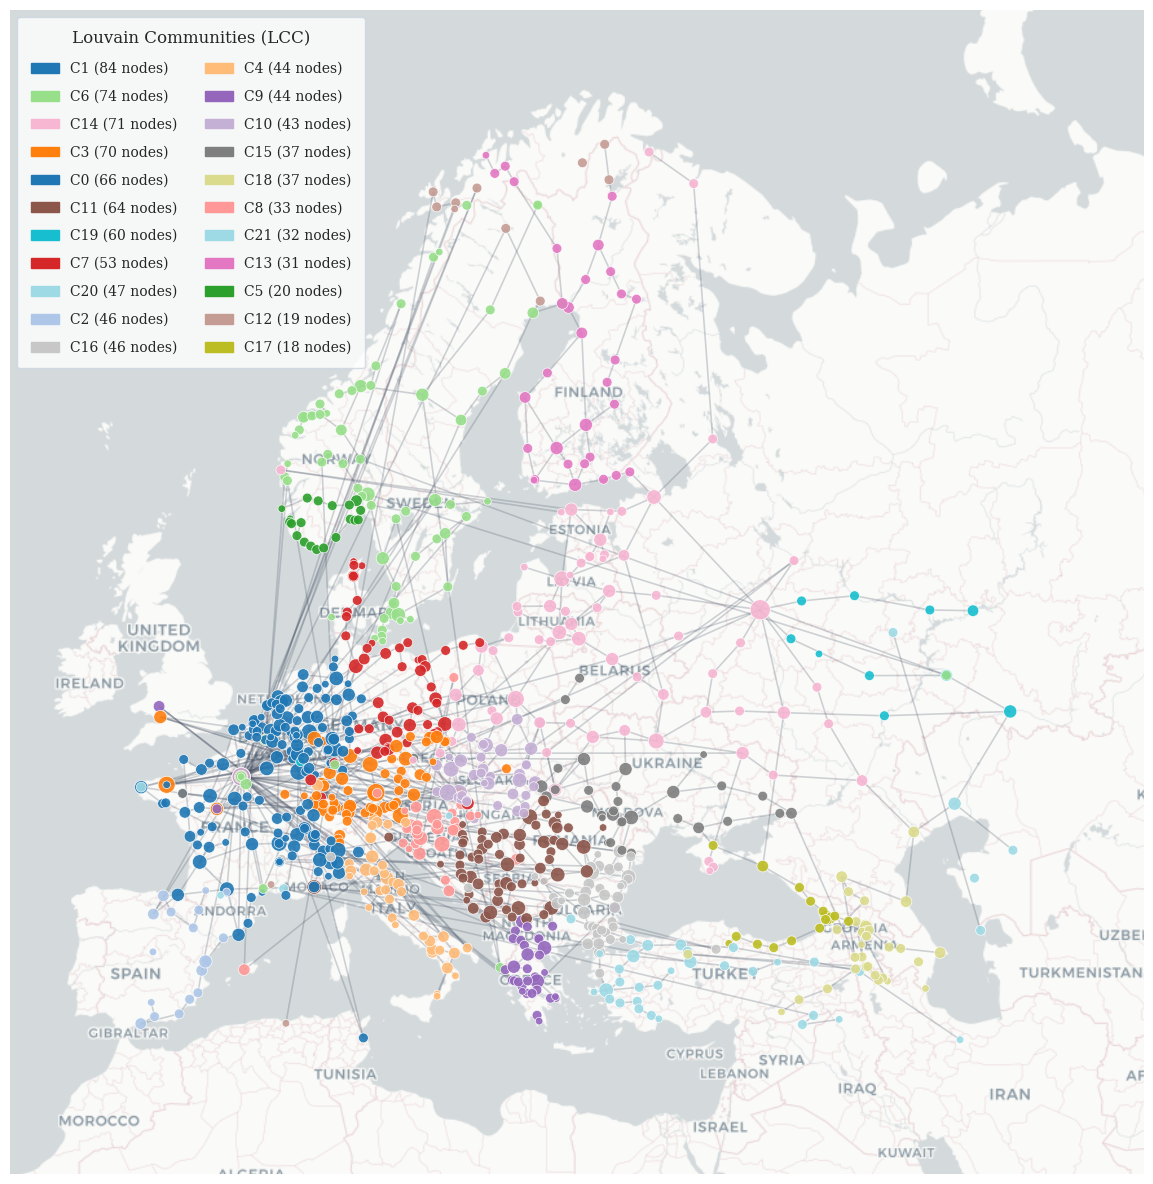

In [ ]:
import matplotlib.patches as mpatches
from collections import Counter
import networkx as nx
import community as community_louvain
import geopandas as gpd
import contextily as ctx
from shapely.geometry import Point, LineString

def cargar_datos():
    G = nx.Graph()
    with open('subelj_euroroad/ent.subelj_euroroad_euroroad.city.name', 'r', encoding='utf-8') as f:
        cities = [line.strip() for line in f if line.strip()]
    for idx, city_name in enumerate(cities, start=1):
        G.add_node(idx, name=city_name)
    with open('subelj_euroroad/out.subelj_euroroad_euroroad', 'r') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('%'):
                continue
            parts = line.split()
            if len(parts) >= 2:
                G.add_edge(int(parts[0]), int(parts[1]))
    return G

G_full = cargar_datos()
giant_components = sorted(nx.connected_components(G_full), key=len, reverse=True)
G = G_full.subgraph(giant_components[0]).copy()

print(f"Full Network  | Nodes: {G_full.number_of_nodes()} | Edges: {G_full.number_of_edges()}")
print(f"Giant Comp.   | Nodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()}")

partition = community_louvain.best_partition(G, random_state=42)
n_communities = len(set(partition.values()))
modularity = community_louvain.modularity(partition, G)

print(f"Communities found : {n_communities}")
print(f"Modularity Q      : {modularity:.4f}")

sizes = Counter(partition.values())

CACHE_FILE = 'coordenadas_ciudades.json'
if not os.path.exists(CACHE_FILE):
    raise FileNotFoundError(f"No se encontró {CACHE_FILE}.")

with open(CACHE_FILE, 'r', encoding='utf-8') as f:
    cache_data = json.load(f)
    posiciones = {int(k): tuple(v) for k, v in cache_data.items()}

nodos_data = []
for node in G.nodes():
    if node in posiciones:
        coords = posiciones[node]
        if (-5 <= coords[0] <= 55) and (35 <= coords[1] <= 70):
            nodos_data.append({'geometry': Point(coords),'name': G.nodes[node]['name'],'node_id': node,'community': partition[node],'degree': G.degree(node)})

gdf_nodes = gpd.GeoDataFrame(nodos_data, crs="EPSG:4326")
nodos_mapeados = set(gdf_nodes['node_id'])

lineas_geom = [
    LineString([posiciones[u], posiciones[v]])
    for u, v in G.edges() if u in nodos_mapeados and v in nodos_mapeados]
gdf_edges = gpd.GeoDataFrame(geometry=lineas_geom, crs="EPSG:4326")
gdf_nodes = gdf_nodes.to_crs(epsg=3857)
gdf_edges = gdf_edges.to_crs(epsg=3857)
plt.rcParams['font.family'] = 'serif'
cmap = plt.cm.get_cmap("tab20", n_communities)
BG = "#ffffff"
os.makedirs('figs', exist_ok=True)

node_colors = [cmap(cid) for cid in gdf_nodes['community']]
node_sizes = gdf_nodes['degree'] * 20 + 10

fig, ax = plt.subplots(figsize=(16, 12))
ax.set_facecolor(BG)
gdf_edges.plot(ax=ax, color='#4a5568', linewidth=1.2, alpha=0.25, zorder=2)
ax.scatter(gdf_nodes.geometry.x,gdf_nodes.geometry.y,s=node_sizes,c=node_colors,alpha=0.9,edgecolor='#ffffff',linewidth=0.5,zorder=3)
handles = [mpatches.Patch(color=cmap(cid), label=f"C{cid} ({sizes[cid]} nodes)")for cid in sorted(sizes, key=lambda x: -sizes[x])]
ax.legend(handles=handles, title="Louvain Communities (LCC)", loc="upper left", frameon=True,facecolor='white',edgecolor='#cbd5e1',labelspacing=1.0,borderpad=1.0,fontsize=10,ncol=2)

ctx.add_basemap(ax=ax, source=ctx.providers.CartoDB.Positron, attribution ="")

bounds = gdf_nodes.total_bounds
x_margin = (bounds[2] - bounds[0]) * 0.15
y_margin = (bounds[3] - bounds[1]) * 0.15
ax.set_xlim(bounds[0] - x_margin, bounds[2] + x_margin)
ax.set_ylim(bounds[1] - y_margin, bounds[3] + y_margin)
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
plt.axis('off')

plt.tight_layout()
plt.savefig('figs/louvain_map_europe.png', dpi=300, bbox_inches='tight')
plt.show()


# assignment 4

In [ ]:
degree_sequence = [d for n, d in G.degree()]

def generate_clean_cm_instance(deg_seq):
    if sum(deg_seq) % 2 != 0:
        deg_seq = deg_seq.copy()
        deg_seq[0] += 1
    G_multigraph = nx.configuration_model(deg_seq, seed=None)
    G_simple = nx.Graph(G_multigraph)
    G_simple.remove_edges_from(nx.selfloop_edges(G_simple))
    return G_simple

def compute_topological_properties(graph):
    props = {}
    lcc_nodes = sorted(nx.connected_components(graph), key=len, reverse=True)[0]
    G_lcc = graph.subgraph(lcc_nodes).copy()
    props['nodes'] = G_lcc.number_of_nodes()
    props['edges'] = G_lcc.number_of_edges()
    props['avg_clustering'] = nx.average_clustering(G_lcc)
    props['avg_path_length'] = nx.average_shortest_path_length(G_lcc)
    partition = community_louvain.best_partition(G_lcc)
    props['modularity'] = community_louvain.modularity(partition, G_lcc)
    props['communities_count'] = len(set(partition.values()))
    return props

print("--- Calculating 1 CM random network instance ---")
G_single_cm = generate_clean_cm_instance(degree_sequence)
single_metrics = compute_topological_properties(G_single_cm)

for k, v in single_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

print("\n--- Running 100 CM random network realizations ---")
n_realizations = 100

accumulated_metrics = {'nodes': [], 'edges': [], 'avg_clustering': [], 'avg_path_length': [], 'modularity': [], 'communities_count': []}

for i in range(n_realizations):
    G_cm_instance = generate_clean_cm_instance(degree_sequence)
    metrics = compute_topological_properties(G_cm_instance)
    
    for key in accumulated_metrics.keys():
        accumulated_metrics[key].append(metrics[key])

print("\n--- Average Topological Properties over 100 Realizations ---")
for key, values in accumulated_metrics.items():
    mean_val = np.mean(values)
    std_val = np.std(values)
    print(f"Average {key}: {mean_val:.4f} (± {std_val:.4f})")

--- Calculating 1 CM random network instance ---
nodes: 1145
edges: 1397
avg_clustering: 0.0003
avg_path_length: 9.6878
modularity: 0.7924
communities_count: 30

--- Running 100 CM random network realizations ---

--- Average Topological Properties over 100 Realizations ---
Average nodes: 1141.5900 (± 9.1511)
Average edges: 1394.0700 (± 7.0870)
Average avg_clustering: 0.0010 (± 0.0010)
Average avg_path_length: 9.6664 (± 0.1029)
Average modularity: 0.7885 (± 0.0041)
Average communities_count: 29.0100 (± 1.5906)
